# Online Retail Sales Performance Analysis

**Business Question:** Bagaimana pola pembelian customer dan performa produk pada bisnis retail online, serta customer segment mana yang paling bernilai untuk strategi retensi dan pertumbuhan revenue?

**Dataset:** Online Retail II (Kaggle) — transaksi retail online periode 2010-2011.

**Alur notebook ini:**
1. Load & inspeksi data
2. Data cleaning
3. Exploratory Data Analysis (EDA)
4. Visualisasi
5. Export data bersih untuk dianalisis lebih lanjut di MySQL


## 1. Import Library & Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting tampilan plot
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Load dataset (sesuaikan nama file dengan yang kamu download dari Kaggle)
df = pd.read_csv('online_retail_II.csv', encoding='ISO-8859-1')

df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [4]:
# Info umum dataset
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  str    
 1   StockCode    541910 non-null  str    
 2   Description  540456 non-null  str    
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  str    
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [5]:
# Ukuran data & statistik deskriptif awal
print("Jumlah baris & kolom:", df.shape)
df.describe()


Jumlah baris & kolom: (541910, 8)


,Quantity,Price,Customer ID
count,541910.000000,541910.000000,406830.000000
mean,9.552234,4.611138,15287.684160
std,218.080957,96.759765,1713.603074
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## 2. Data Cleaning

Langkah-langkah cleaning yang akan dilakukan:
- Cek dan tangani missing values
- Buang transaksi retur (Quantity negatif) untuk analisis sales murni
- Buang Price yang tidak valid (<= 0)
- Buat kolom Revenue
- Konversi tipe data tanggal


In [6]:
# Cek missing values per kolom
df.isnull().sum().sort_values(ascending=False)


Customer ID    135080
Description      1454
StockCode           0
Invoice             0
Quantity            0
InvoiceDate         0
Price               0
Country             0
dtype: int64

In [7]:
# CustomerID banyak yang kosong -> transaksi tanpa akun/guest
# Untuk analisis customer behavior, kita buang baris tanpa CustomerID
df_clean = df.dropna(subset=['Customer ID']).copy()

print(f"Baris sebelum cleaning: {len(df)}")
print(f"Baris setelah drop missing CustomerID: {len(df_clean)}")


Baris sebelum cleaning: 541910
Baris setelah drop missing CustomerID: 406830


In [8]:
# Cek transaksi dengan Quantity negatif (biasanya retur/cancelled order)
neg_qty = df_clean[df_clean['Quantity'] < 0]
print(f"Jumlah transaksi dengan Quantity negatif: {len(neg_qty)}")
neg_qty.head()


Jumlah transaksi dengan Quantity negatif: 8905


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
141,C536379,D,Discount,-1,12/1/10 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/10 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/10 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom


In [9]:
# Untuk fokus analisis sales (bukan retur), kita pisahkan
df_returns = df_clean[df_clean['Quantity'] < 0].copy()   # simpan terpisah, bisa dianalisis khusus nanti
df_sales = df_clean[df_clean['Quantity'] > 0].copy()

# Buang juga Price yang tidak valid
df_sales = df_sales[df_sales['Price'] > 0]

print(f"Jumlah transaksi sales valid: {len(df_sales)}")
print(f"Jumlah transaksi retur: {len(df_returns)}")


Jumlah transaksi sales valid: 397885
Jumlah transaksi retur: 8905


In [10]:
# Buat kolom Revenue
df_sales['Revenue'] = df_sales['Quantity'] * df_sales['Price']

# Konversi InvoiceDate ke datetime
df_sales['InvoiceDate'] = pd.to_datetime(df_sales['InvoiceDate'])

# Tambah kolom bantu untuk analisis waktu
df_sales['YearMonth'] = df_sales['InvoiceDate'].dt.to_period('M')
df_sales['DayOfWeek'] = df_sales['InvoiceDate'].dt.day_name()

df_sales.head()


C:\Users\bekas\AppData\Local\Temp\ipykernel_14372\3455077155.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_sales['InvoiceDate'] = pd.to_datetime(df_sales['InvoiceDate'])


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,YearMonth,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,Wednesday


In [11]:
# Cek duplikat
duplicates = df_sales.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicates}")

df_sales = df_sales.drop_duplicates()
print(f"Jumlah baris setelah hapus duplikat: {len(df_sales)}")


Jumlah baris duplikat: 5192
Jumlah baris setelah hapus duplikat: 392693


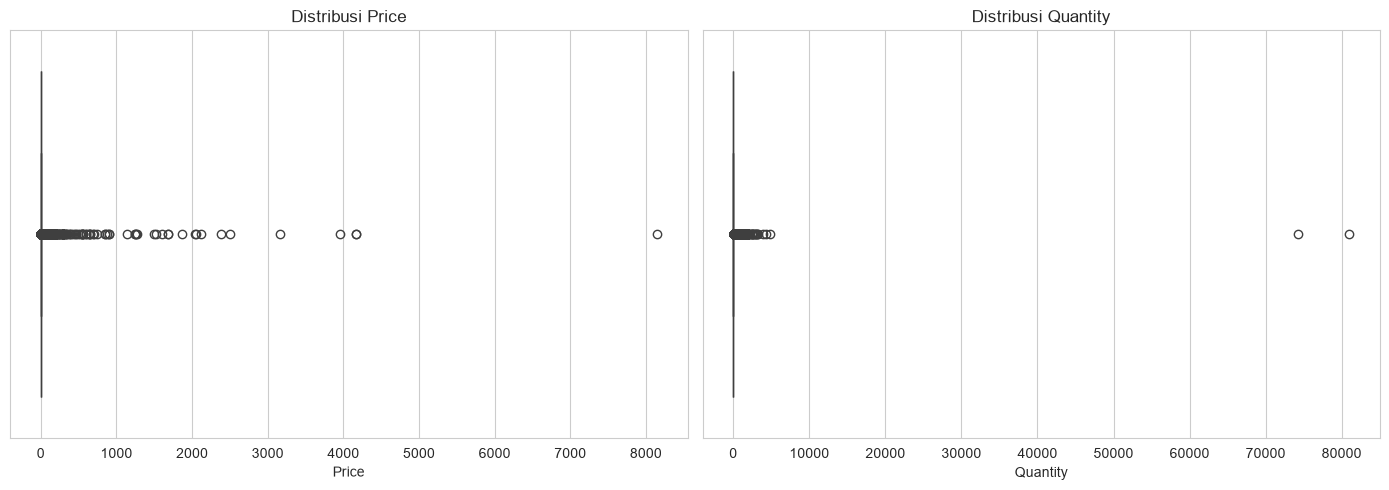

In [12]:
# Cek outlier sederhana di Price dan Quantity pakai boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=df_sales['Price'], ax=axes[0])
axes[0].set_title('Distribusi Price')

sns.boxplot(x=df_sales['Quantity'], ax=axes[1])
axes[1].set_title('Distribusi Quantity')

plt.tight_layout()
plt.show()

# Catatan: outlier ekstrem bisa jadi transaksi wholesale/bulk order, bukan error.


## 3. Exploratory Data Analysis (EDA)

In [13]:
# Total revenue keseluruhan
total_revenue = df_sales['Revenue'].sum()
total_orders = df_sales['Invoice'].nunique()
total_customers = df_sales['Customer ID'].nunique()

print(f"Total Revenue     : £{total_revenue:,.2f}")
print(f"Total Orders      : {total_orders:,}")
print(f"Total Customers   : {total_customers:,}")
print(f"Avg Revenue/Order : £{total_revenue/total_orders:,.2f}")


Total Revenue     : £8,887,226.89
Total Orders      : 18,532
Total Customers   : 4,338
Avg Revenue/Order : £479.56


In [14]:
# Revenue per bulan
monthly_revenue = df_sales.groupby('YearMonth')['Revenue'].sum()
monthly_revenue


YearMonth
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517208.440
Freq: M, Name: Revenue, dtype: float64

In [15]:
# Top 10 negara berdasarkan revenue
top_countries = df_sales.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
top_countries


Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208952.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

In [16]:
# Top 10 produk terlaris berdasarkan Quantity terjual
top_products = df_sales.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top_products


Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

In [17]:
# Top 10 produk berdasarkan Revenue
top_products_revenue = df_sales.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
top_products_revenue


Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77821.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64

### RFM Analysis (Recency, Frequency, Monetary)

RFM membantu segmentasi customer.


In [18]:
# Menghitung RFM (Recency, Frequency, Monetary) untuk segmentasi pelanggan
# Mencatat snapshot date sebagai referensi untuk menghitung recency
snapshot_date = df_sales['InvoiceDate'].max() + pd.Timedelta(days=1)

# Membuat dataframe RFM
rfm = df_sales.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,   # Recency
    'Invoice': 'nunique',                                     # Frequency
    'Revenue': 'sum'                                            # Monetary
}).rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'Revenue': 'Monetary'
})

rfm.sort_values('Monetary', ascending=False).head(10)


,Recency,Frequency,Monetary
Customer ID,,,
14646.0,2,73,280206.02
18102.0,1,60,259657.30
17450.0,8,46,194390.79
16446.0,1,2,168472.50
14911.0,1,201,143711.17
12415.0,24,21,124914.53
14156.0,10,55,117210.08
17511.0,3,31,91062.38
16029.0,39,63,80850.84


In [19]:
# Simple segmentation: bagi customer ke dalam quartile skor RFM
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4]).astype(int)

# Menggabungkan skor RFM menjadi satu skor total
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def segment(score):
    if score >= 10:
        return 'Champion'
    elif score >= 7:
        return 'Loyal Customer'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost Customer'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)
rfm['Segment'].value_counts()


Segment
At Risk           1495
Loyal Customer    1276
Champion          1267
Lost Customer      300
Name: count, dtype: int64

In [20]:
# Menghitung persentase revenue per segment
rfm['Percentage Revenue'] = (rfm['Monetary'] / rfm['Monetary'].sum() * 100)

total_revenue_rfm = rfm['Percentage Revenue'].groupby(rfm['Segment']).sum().sort_values(ascending=False)

total_revenue_rfm.round(2)

Segment
Champion          76.82
Loyal Customer    15.41
At Risk            7.23
Lost Customer      0.54
Name: Percentage Revenue, dtype: float64

## 4. Visualisasi

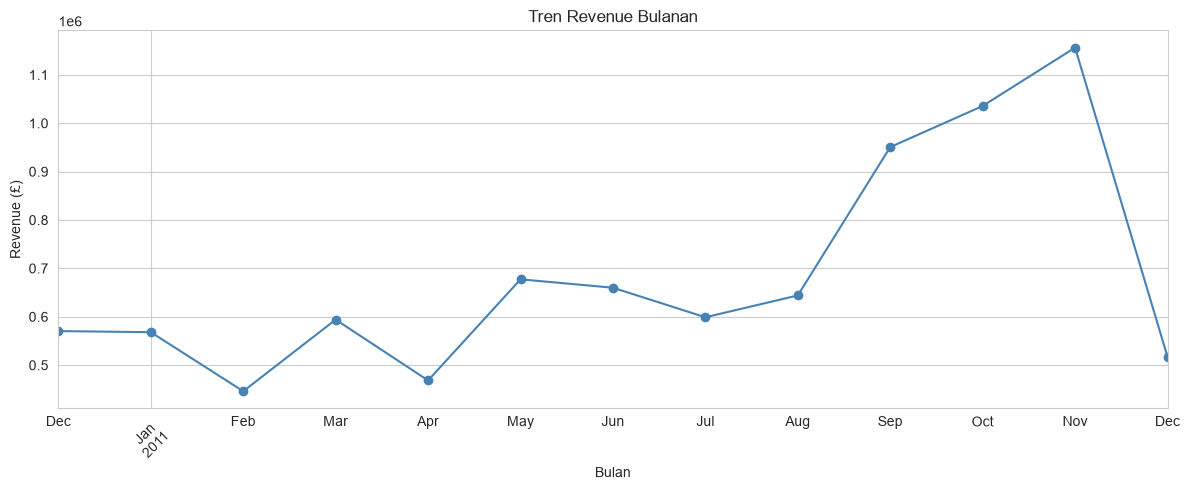

In [21]:
# Tren revenue bulanan
plt.figure(figsize=(12, 5))
monthly_revenue.plot(kind='line', marker='o', color='steelblue')
plt.title('Tren Revenue Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


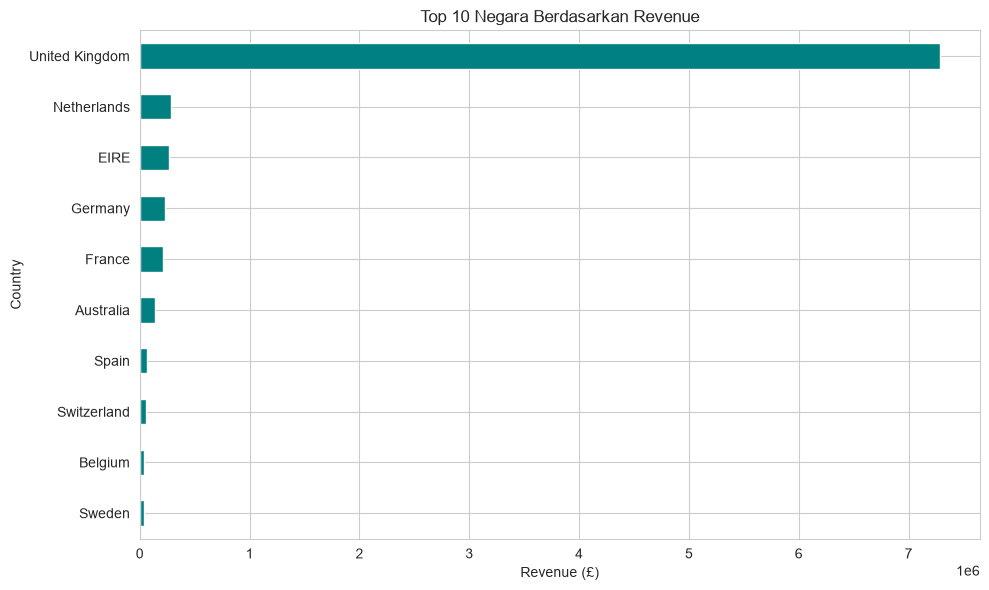

In [22]:
# Top 10 negara berdasarkan revenue
plt.figure(figsize=(10, 6))
top_countries.plot(kind='barh', color='teal')
plt.title('Top 10 Negara Berdasarkan Revenue')
plt.xlabel('Revenue (£)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


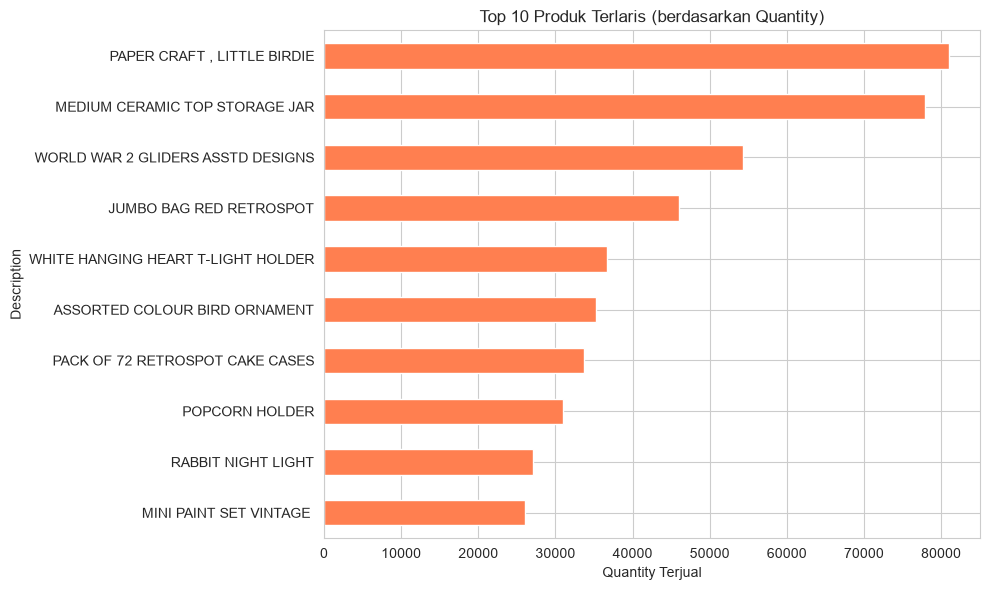

In [23]:
# Top 10 produk terlaris
plt.figure(figsize=(10, 6))
top_products.plot(kind='barh', color='coral')
plt.title('Top 10 Produk Terlaris (berdasarkan Quantity)')
plt.xlabel('Quantity Terjual')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


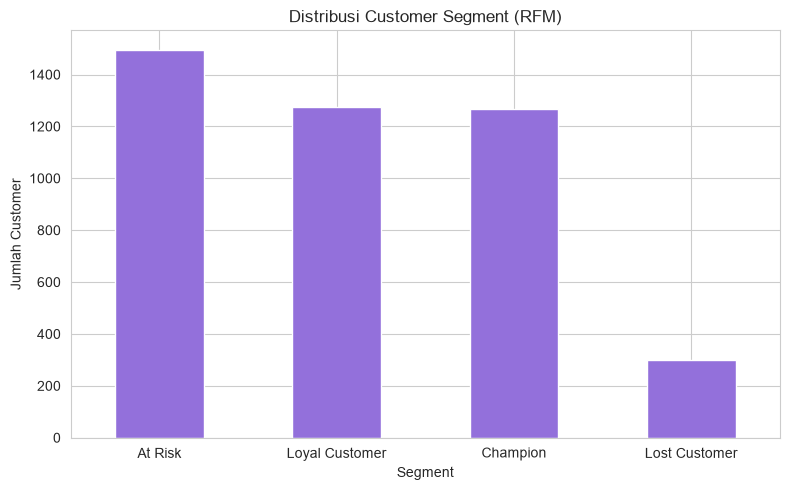

In [24]:
# Distribusi customer segment (hasil RFM)
plt.figure(figsize=(8, 5))
rfm['Segment'].value_counts().plot(kind='bar', color='mediumpurple')
plt.title('Distribusi Customer Segment (RFM)')
plt.xlabel('Segment')
plt.ylabel('Jumlah Customer')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


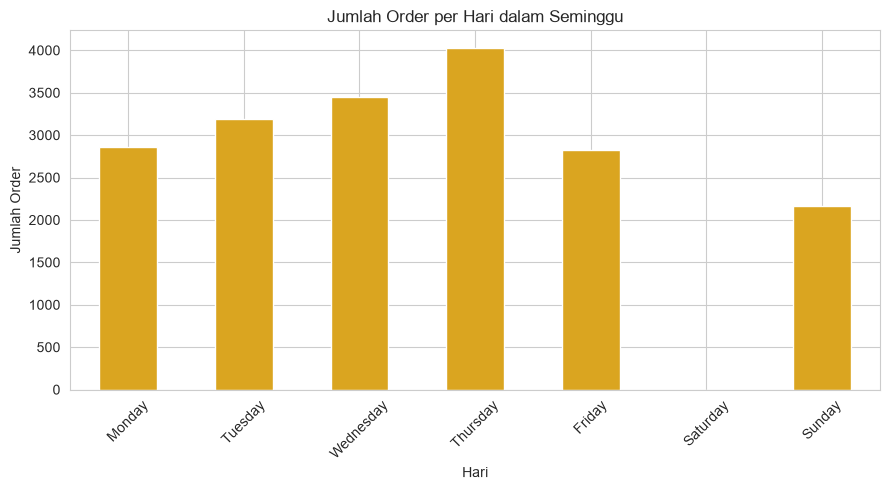

In [25]:
# Pola transaksi berdasarkan hari dalam seminggu
order_by_day = df_sales.groupby('DayOfWeek')['Invoice'].nunique()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
order_by_day = order_by_day.reindex(day_order)

plt.figure(figsize=(9, 5))
order_by_day.plot(kind='bar', color='goldenrod')
plt.title('Jumlah Order per Hari dalam Seminggu')
plt.xlabel('Hari')
plt.ylabel('Jumlah Order')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 5. Ringkasan Insight

1. **Revenue sangat terkonsentrasi di UK** \
United Kingdom menyumbang **82% dari total revenue** (£7,28 juta), jauh di atas negara kedua (Netherlands, £285rb). Ini menunjukkan basis pelanggan masih sangat domestik dan membuka peluang ekspansi ke Netherlands/Eire/Germany.
2. **Prinsip Pareto terbukti kuat pada basis customer** \
Hasil RFM segmentation menunjukkan segmen **"Champion"** memiliki customer sebanyak 1.267 dari 4.338 customer (29%), tapi menyumbang **76,8% dari total revenue**. Sebaliknya, **"Lost Customer"** (300 orang) hanya menyumbang 0,5% revenue. Fokus retensi sebaiknya diarahkan ke segmen Champion & Loyal Customer.
3. **Ada tren pertumbuhan kuat menjelang Q4** \
Revenue naik signifikan dari Agustus (£644rb) ke November (**puncak tertinggi, £1,15 juta**), konsisten dengan pola belanja musim liburan. Desember turun karena data terpotong (cuma sampai awal Desember 2011).
4. **Tidak ada transaksi di hari Sabtu** \
Pola order tersebar di hari Senin–Jumat dengan sedikit transaksi di hari Minggu, mengindikasikan karakteristik bisnis ini kemungkinan B2B/wholesale, bukan retail konsumen harian biasa.
5. **Produk terlaris didoinasi barang dekorasi/gift** \
Item seperti "PAPER CRAFT LITTLE BIRDIE" dan "REGENCY CAKESTAND 3 TIER" menjadi kontributor revenue tertinggi, konsisten dengan positioning bisnis sebagai penjual barang dekorasi/gift.

## 6. Export Data Bersih untuk Analisis Lanjutan di MySQL

In [ ]:
# Export data sales yang sudah bersih
# Hapus tanda komentar jika ingin mengekspor ke CSV

# df_sales.to_csv('online_retail_clean.csv', index=False)

print("Export selesai: online_retail_clean.csv")

Export selesai: online_retail_clean.csv


## 7. Export Data Bersih untuk Membuat Dashboard di Tableau

In [ ]:
# Install dulu kalau belum ada engine-nya
# pip install openpyxl

# Hapus terlebih dahulu tanda komentar jika ingin mengekspor ke Excel

# with pd.ExcelWriter('retail_analysis_for_tableau.xlsx', engine='openpyxl') as writer:
#    df_sales.to_excel(writer, sheet_name='transactions', index=False)
#    rfm.reset_index().to_excel(writer, sheet_name='customer_segments', index=False)

print("Export selesai: retail_analysis_for_tableau.xlsx")

Export selesai: retail_analysis_for_tableau.xlsx
